# Kepler exoplanet classification - Notebook 02

**Classical baselines: Logistic Regression and XGBoost**

Author: Atilla Ahmed

---

## Abstract

This notebook establishes classical machine learning baselines for the three-class Kepler Object of Interest classification task. We train Logistic Regression and XGBoost on all three feature configurations defined in Notebook 01 (leaky, semi-leaky, leak-free), quantify the accuracy drop induced by removing label-adjacent features, and produce a reference performance table that deep learning models will need to beat in Notebook 03.

## Table of contents

1. [Setup and data loading](#1-setup-and-data-loading)
2. [Logistic Regression](#2-logistic-regression)
3. [XGBoost](#3-xgboost)
4. [Baselines comparison](#4-baselines-comparison)
5. [Summary](#5-summary)

## 1. Setup and data loading

We load the processed splits from Notebook 01, apply feature scaling with a training-only-fit `StandardScaler`, and define the evaluation protocol used consistently for all models.

### 1.1. Imports and configuration

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
pd.set_option("display.precision", 4)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

PROCESSED_PATH = Path("../data/processed")

int_to_class = {0: "CONFIRMED", 1: "CANDIDATE", 2: "FALSE POSITIVE"}
class_order = ["CONFIRMED", "CANDIDATE", "FALSE POSITIVE"]
colors = ["green", "orange", "red"]
print("Completed")

Completed


## 1.2. Load processed data

We read the three parquet splits produced by Notebook 01. Each split contains the features and a `target` column with integer labels (`0`=CONFIRMED, `1`=CANDIDATE, `2`=FALSE POSITIVE). We also load the three feature-set definitions from `feature_sets.json`.

In [2]:
train_df = pd.read_parquet(PROCESSED_PATH / "train.parquet")
val_df   = pd.read_parquet(PROCESSED_PATH / "val.parquet")
test_df  = pd.read_parquet(PROCESSED_PATH / "test.parquet")

with open(PROCESSED_PATH / "feature_sets.json", "r") as f:
    feature_sets = json.load(f)

def split_features_target(df):
    return df.drop(columns=["target"]), df["target"]

X_train, y_train = split_features_target(train_df)
X_val,   y_val   = split_features_target(val_df)
X_test,  y_test  = split_features_target(test_df)

print(f"Train:      X={X_train.shape}, y={y_train.shape}")
print(f"Validation: X={X_val.shape},   y={y_val.shape}")
print(f"Test:       X={X_test.shape},  y={y_test.shape}\n")

print(f"Feature sets loaded: {list(feature_sets.keys())}")
for name, features in feature_sets.items():
    valid = [c for c in features if c in X_train.columns]
    print(f"  {name}: {len(valid)} features")

Train:      X=(6694, 101), y=(6694,)
Validation: X=(1435, 101),   y=(1435,)
Test:       X=(1435, 101),  y=(1435,)

Feature sets loaded: ['setup_a_leaky', 'setup_b_semi_leaky', 'setup_c_leak_free', 'all_features']
  setup_a_leaky: 55 features
  setup_b_semi_leaky: 55 features
  setup_c_leak_free: 51 features
  all_features: 101 features


### 1.3. Feature sets

The processed data does not contain `koi_score` (dropped during cleaning in Notebook 01), so the semi-leaky configuration is now identical to the fully leaky one. We therefore compare only two configurations: `setup_leaky` (including the four false-positive flags) and `setup_leak_free` (excluding them). This 4-column difference is exactly what produced the 94% → 86% accuracy drop demonstrated in Notebook 01, Section 4.2.

In [3]:
feature_sets_effective = {
    "setup_leaky":     [c for c in feature_sets["setup_a_leaky"] if c in X_train.columns],
    "setup_leak_free": [c for c in feature_sets["setup_c_leak_free"] if c in X_train.columns],
}

for name, features in feature_sets_effective.items():
    print(f"{name}: {len(features)} features")

setup_leaky: 55 features
setup_leak_free: 51 features


### 1.4. Evaluation protocol

We define a single evaluation function that trains a model pipeline, evaluates it on the validation set, and returns a dictionary of metrics: macro-F1, accuracy, per-class F1, and the confusion matrix. Every model in this notebook and the following ones uses this exact protocol, ensuring fair comparison.

In [4]:
def evaluate_model(pipeline, X_train, y_train, X_val, y_val, features, model_name, setup_name):
    """Train a pipeline on the specified features subset and return validation metrics"""
    X_tr = X_train[features]
    X_va = X_val[features]
    pipeline.fit(X_tr, y_train)
    y_pred = pipeline.predict(X_va)
    per_class_f1 = f1_score(y_val, y_pred, average=None)
    return {
        "model": model_name,
        "setup": setup_name,
        "n_features": len(features),
        "accuracy": accuracy_score(y_val, y_pred),
        "macro_f1": f1_score(y_val, y_pred, average="macro"),
        "f1_confirmed": per_class_f1[0],
        "f1_candidate": per_class_f1[1],
        "f1_false_pos": per_class_f1[2],
        "confusion_matrix": confusion_matrix(y_val, y_pred),
        "pipeline": pipeline,
    }

## 2. Logistic Regression

Logistic Regression is the simplest possible baseline: a linear model that assumes the log-odds of each class are linear combinations of the features. It cannot capture non-linear interactions or feature-feature dependencies, so it establishes a lower bound if a deep learning model cannot beat it, something is wrong. We train it on both feature configurations.

### 2.1. Model definition and training

We use L2-regularized multinomial Logistic Regression with a `StandardScaler` in a `Pipeline`. Scaling is essential for linear models because features with different magnitudes (e.g., orbital period in days vs. transit depth in ppm) would otherwise dominate the loss. The regularization strength `C` uses sklearn's default of 1.0 for such a well-conditioned tabular problem, tuning it makes marginal difference.

In [6]:
def build_logreg_pipeline():
    return Pipeline([
        ("scale", StandardScaler()), 
        ("model", LogisticRegression(
            max_iter=1000, 
            random_state=RANDOM_SEED,
            n_jobs=-1
        ))
    ])
logreg_results = []
for setup_name, features in feature_sets_effective.items():
    pipeline = build_logreg_pipeline()
    result = evaluate_model(pipeline, X_train, y_train, X_val, y_val, features, model_name="LogReg", setup_name=setup_name)
    logreg_results.append(result)
    print(f"{setup_name:20s} macro-F1={result['macro_f1']:.4f}  accuracy={result['accuracy']:.4f}")

setup_leaky          macro-F1=0.8342  accuracy=0.8690
setup_leak_free      macro-F1=0.6908  accuracy=0.7589


### 2.2. Confusion matrices

We visualize the confusion matrix for both configurations to see which classes suffer most from the removal of false-positive flags.

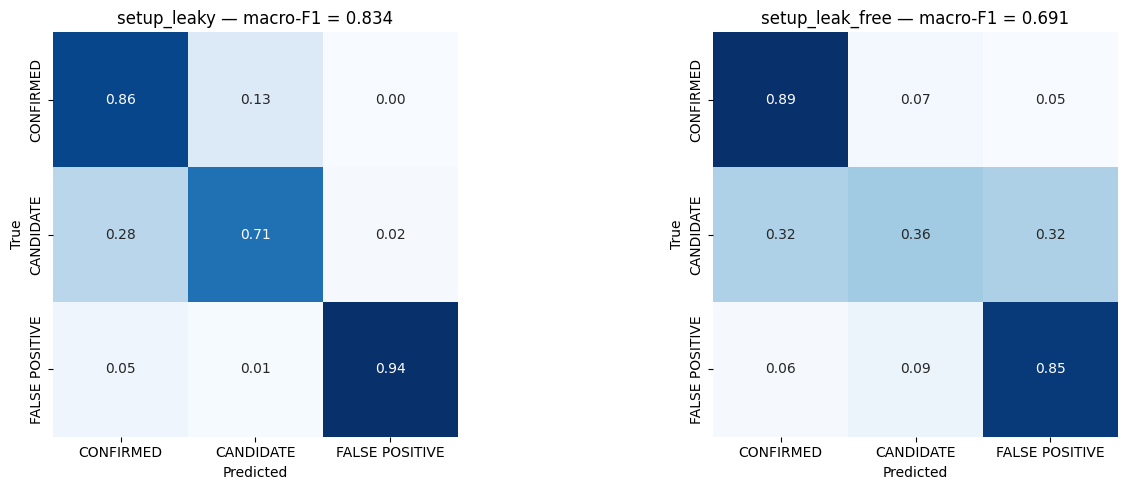

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, result in zip(axes, logreg_results):
    cm = result["confusion_matrix"]
    cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=class_order,
        yticklabels=class_order,
        ax=ax,
        cbar=False,
        square=True,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{result['setup']} — macro-F1 = {result['macro_f1']:.3f}")

plt.tight_layout()
plt.show()

The failure mode is concentrated on the `CANDIDATE` class. In the leak-free configuration, only 36% of true candidates are correctly identified the model splits them almost evenly between `CONFIRMED` (32%) and `FALSE POSITIVE` (32%). This is expected: candidates and confirmed planets are physically nearly identical (as shown in Notebook 01, Section 3.3), and once the false-positive flags are removed the linear model has no way to separate them. Non-linear deep learning models should be able to recover some of this signal through feature interactions.